Mucking about with some network graph libraries. not super happy with any of these.

In [1]:
!uv pip install music21 networkx matplotlib gravis
!uv pip install pyvis

Audited 4 packages in 2ms
Audited 1 package in 2ms


In [2]:
from pyvis.network import Network

In [8]:
from music21 import *
import networkx as nx
import matplotlib.pyplot as plt

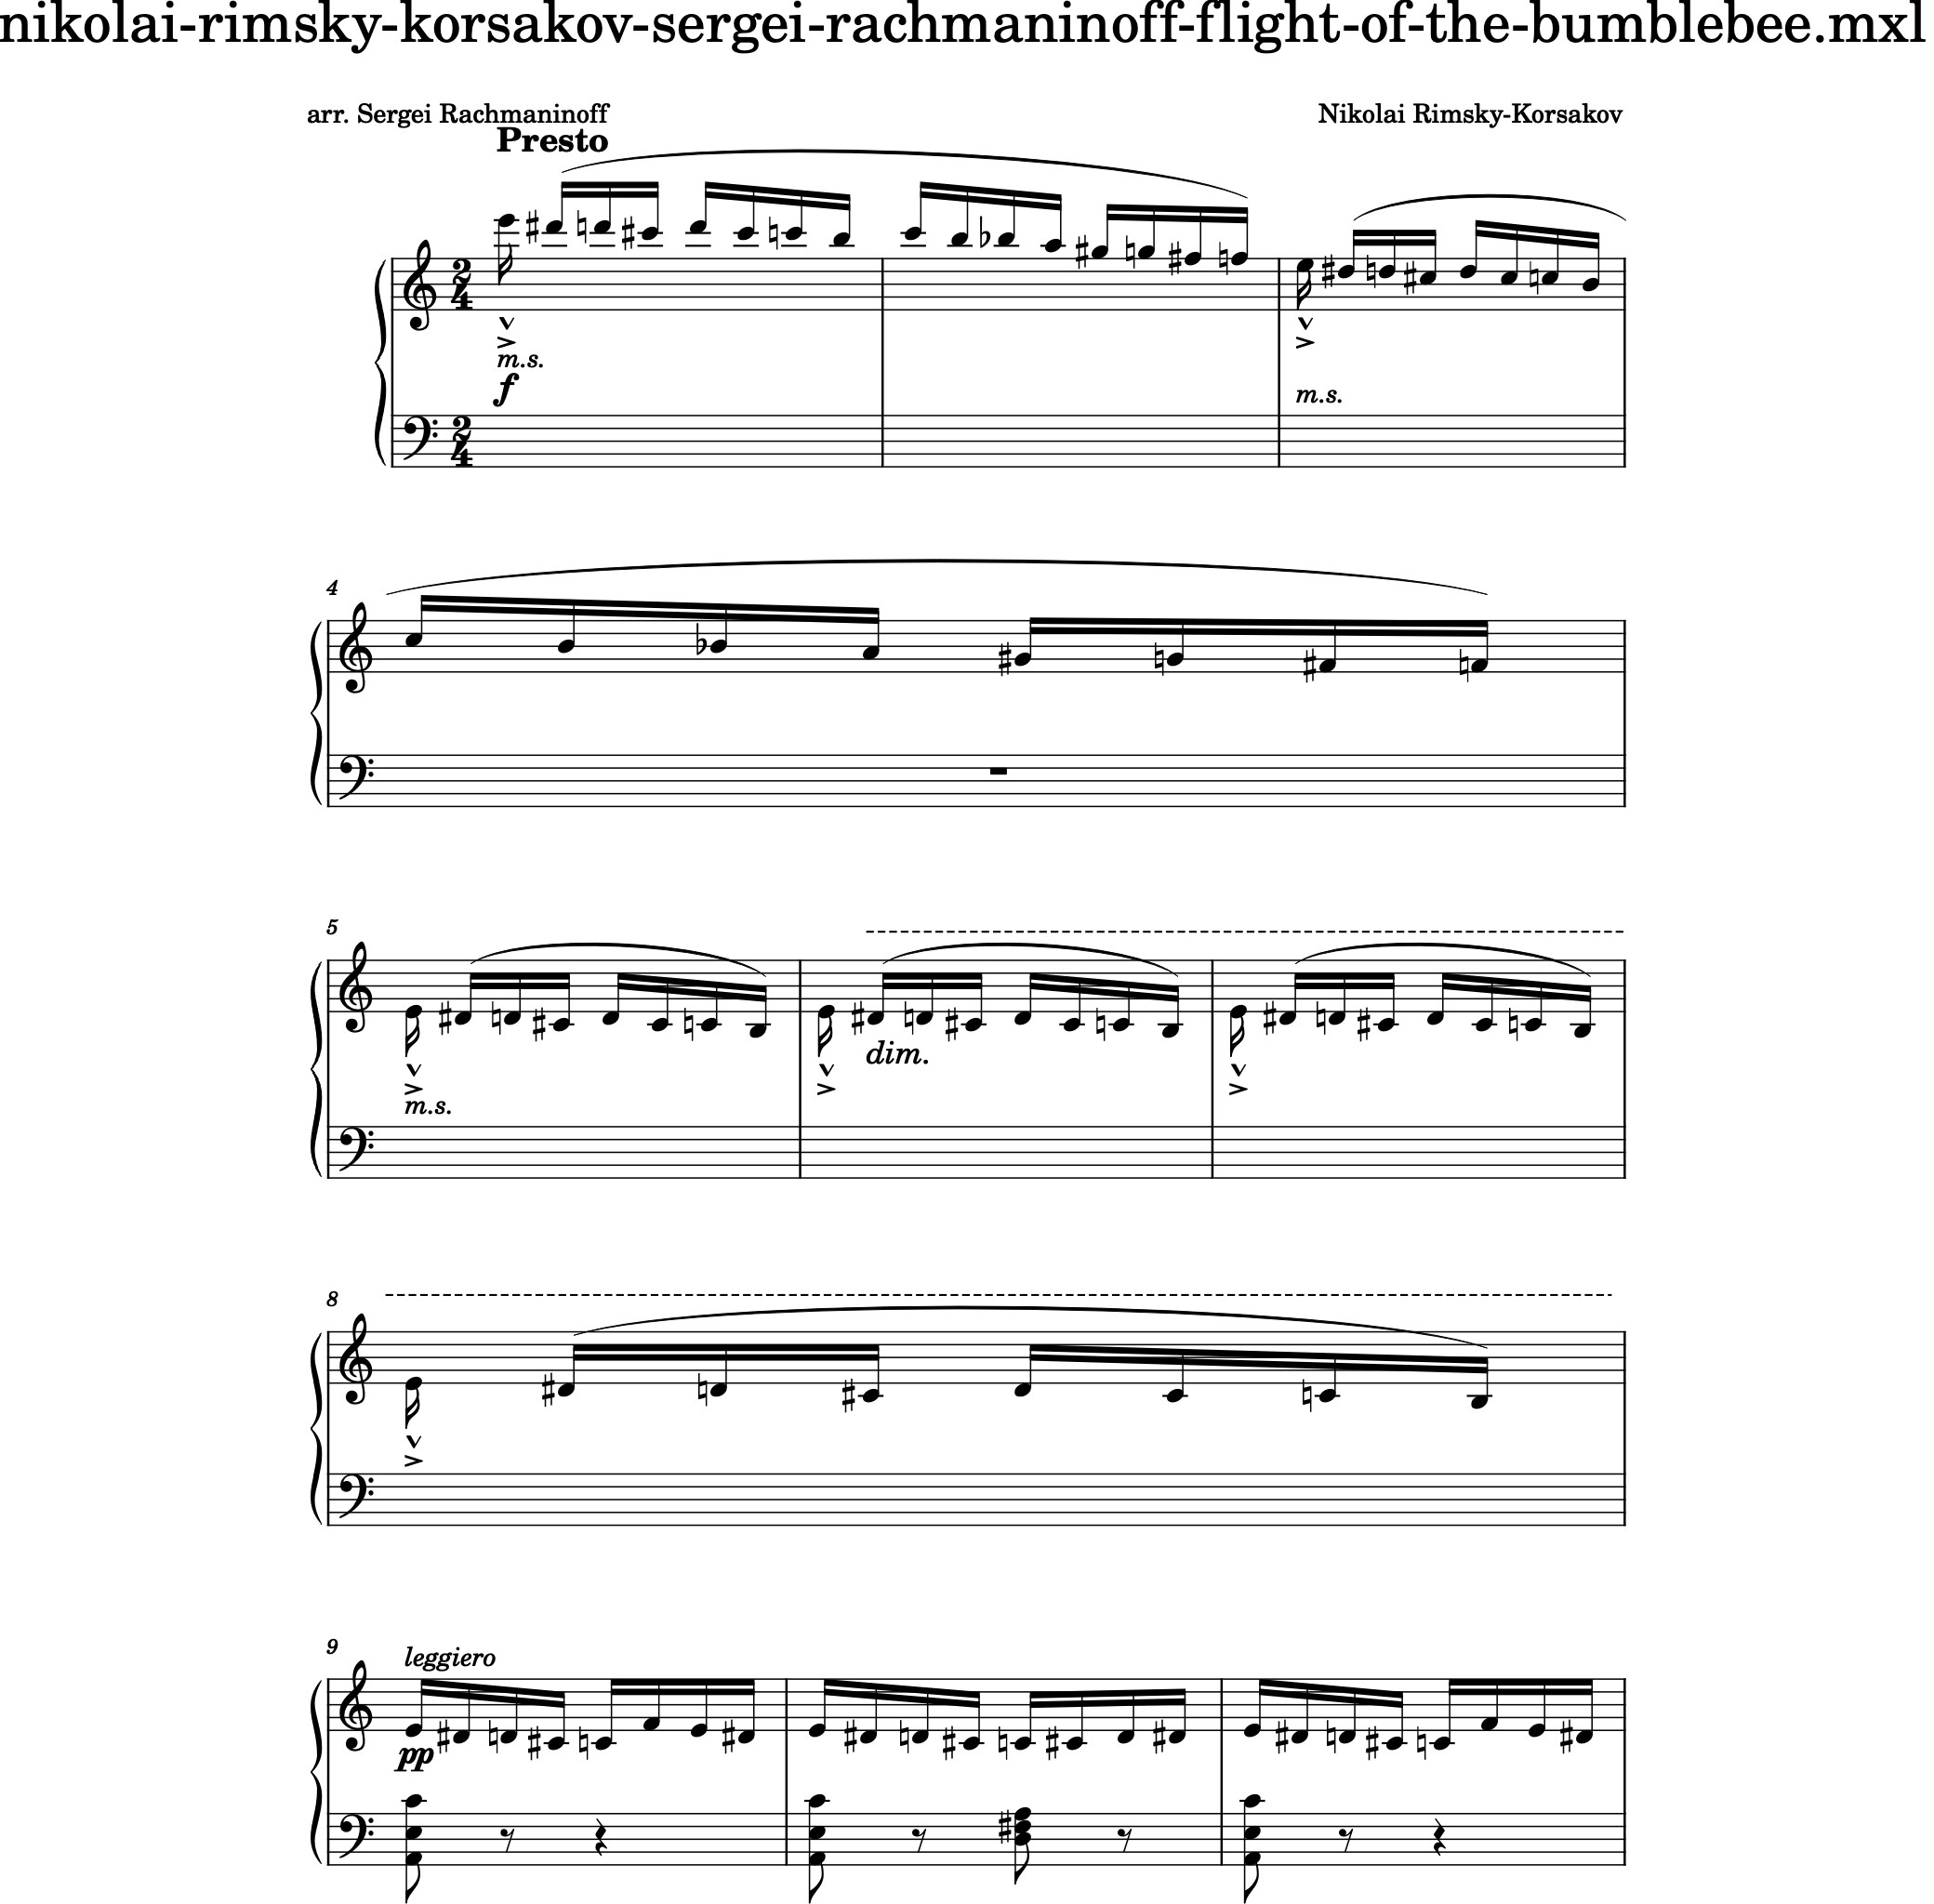

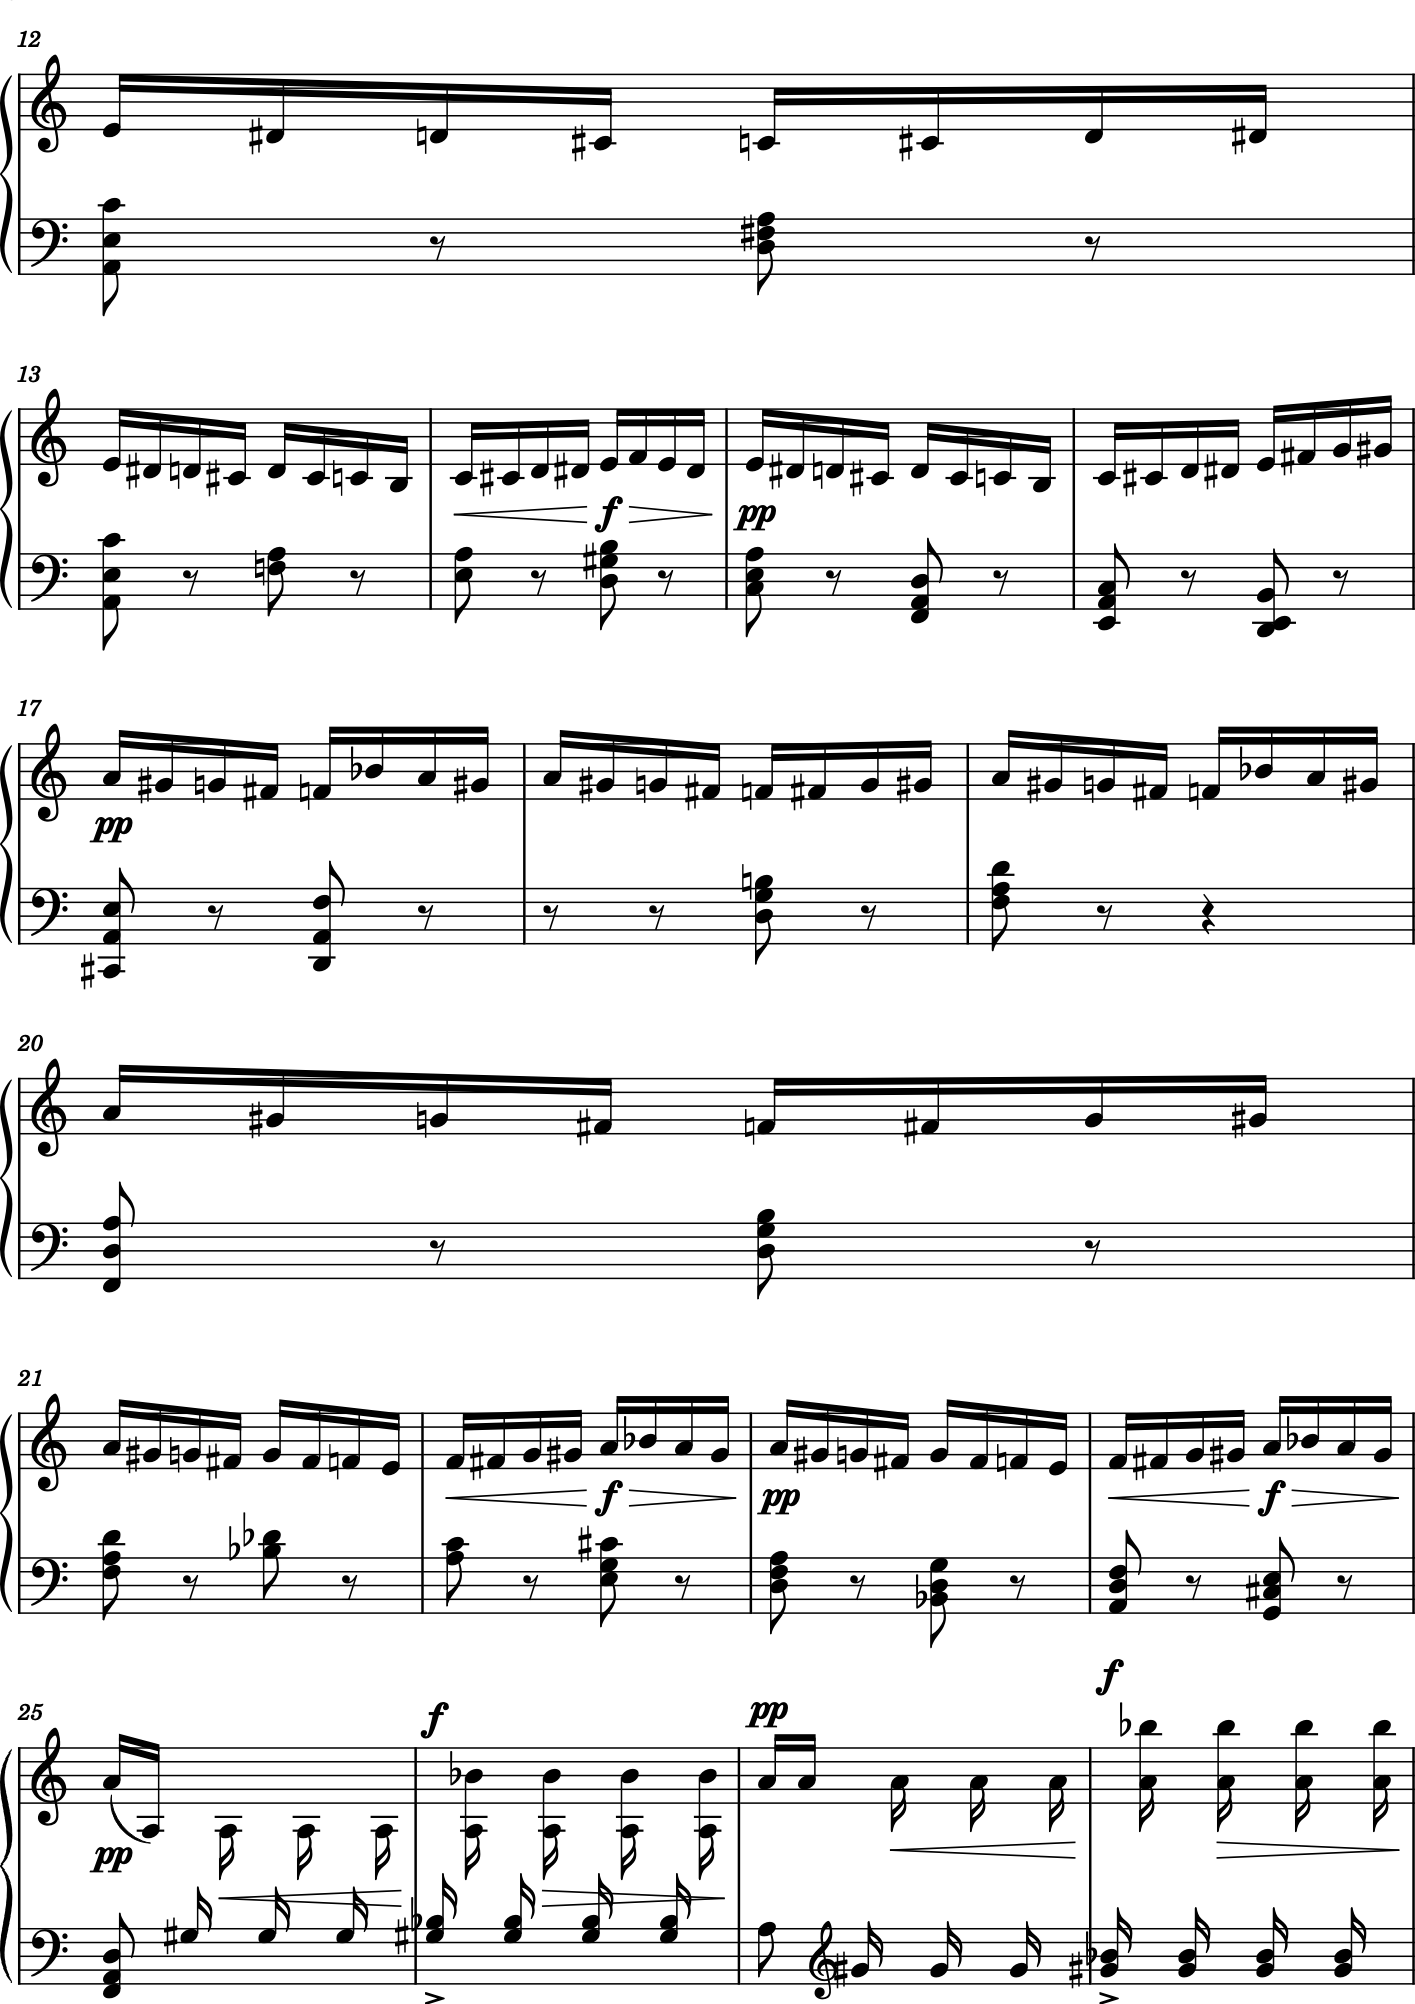

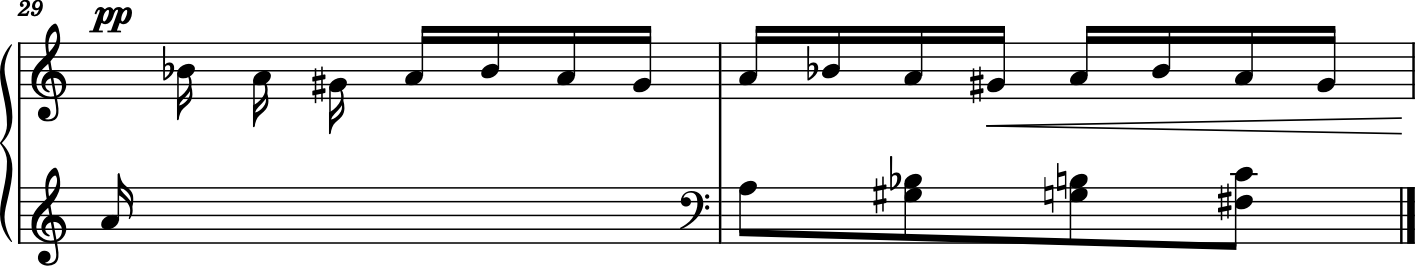

In [4]:
from music21 import *
import copy

score = converter.parse('nikolai-rimsky-korsakov-sergei-rachmaninoff-flight-of-the-bumblebee.mxl')
excerpt = score.measures(1,30)
excerpt.show()

## I. Original

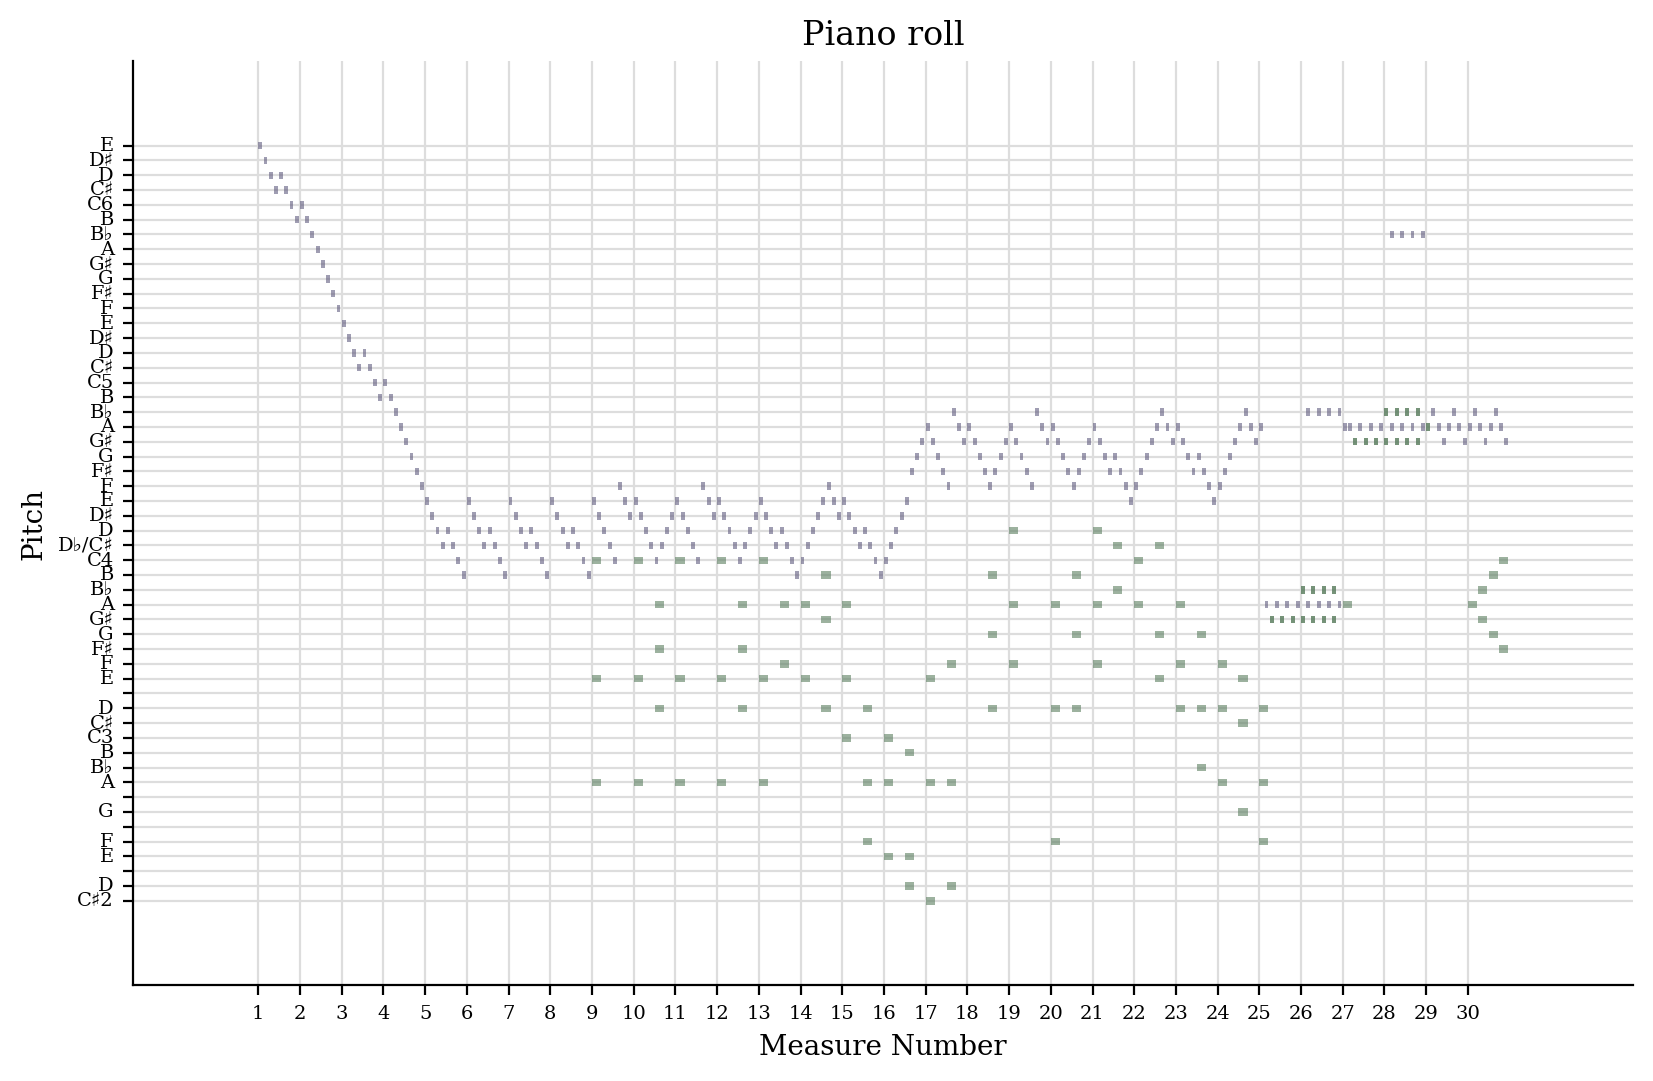

In [5]:
excerpt.plot('pianoroll', colorByPart=True, title="Piano roll")

## II. All notes

In [6]:
def count_transitions(input):
    transitions = {}
    prev_midi = None
    for n in input.recurse().notes:
        current = "0"
        if type(n) == note.Note:
            current = str(n.pitch.midi)
        else:
            current = '_'.join(str(x.pitch.midi) for x in n.notes)
        
        if prev_midi == None:
            prev_midi = current
            continue

        if prev_midi in transitions.keys():
            if current in transitions[prev_midi].keys():
                transitions[prev_midi][current]["weight"] += .01
            else:
                transitions[prev_midi][current] = {"weight": .01}
        else:
            transitions[prev_midi] = {current:{"weight":.01}}
        prev_midi = current
    return transitions

# print(transitions)
rh_transitions = count_transitions(score.getElementsByClass(stream.Part)[0])
lh_transitions = count_transitions(score.getElementsByClass(stream.Part)[1])

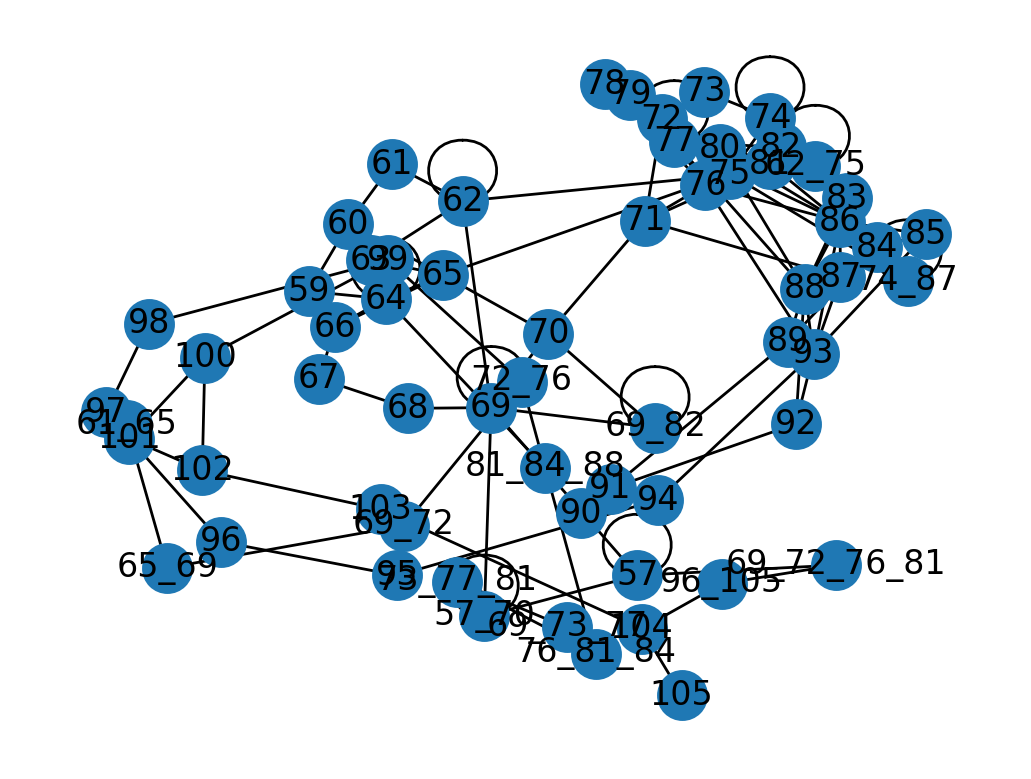

In [9]:
subax1 = plt.subplot(111)
rh_graph = nx.Graph(rh_transitions, create_using=nx.MultiDiGraph)
nx.draw(rh_graph, with_labels=True)

In [12]:
rh_nt = Network(notebook=True, cdn_resources='remote')
# populates the nodes and edges data structures
rh_nt.from_nx(rh_graph)
rh_nt.show('example.html')


example.html


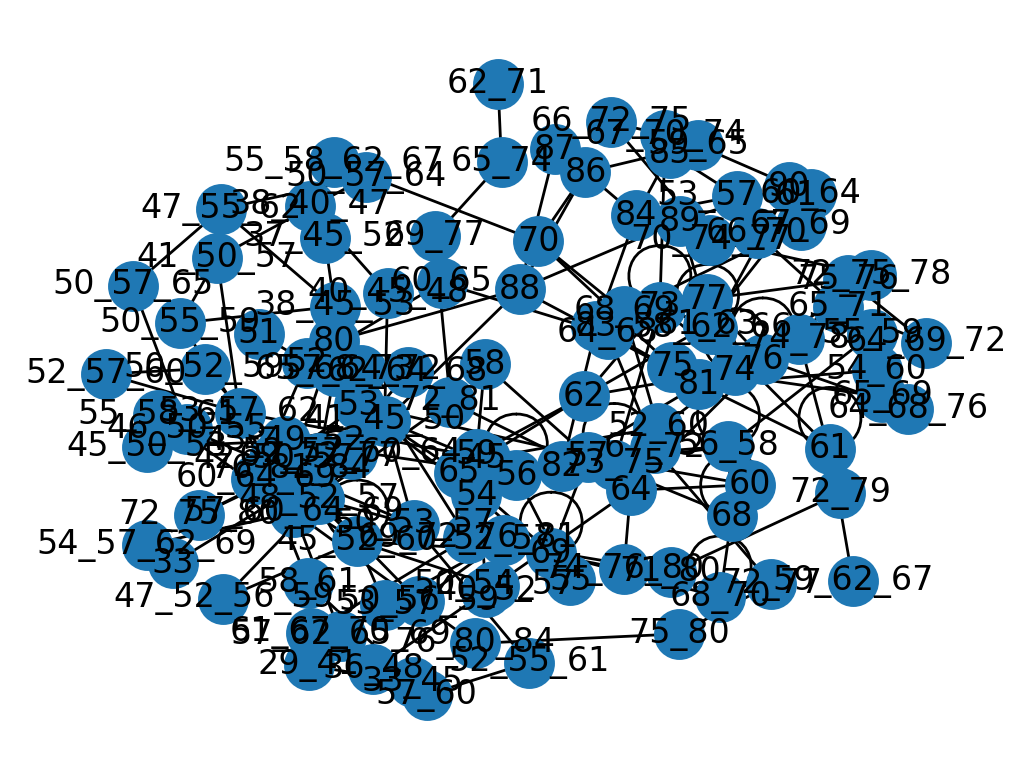

In [10]:
subax2 = plt.subplot(111)
lh_graph = nx.Graph(lh_transitions, title="Left hand")
nx.draw(lh_graph, with_labels=True)

In [11]:
lh_nt = Network(notebook=True, cdn_resources='remote')
# populates the nodes and edges data structures
lh_nt.from_nx(lh_graph)
lh_nt.show('example.html')


example.html
